In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset Iris
data  = load_wine()
X = data.data
y = data.target

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict_proba(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Créer le modèle local NDT
model_classifier = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=13,
    model_regressor=model_classifier
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)


c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Explication locale (feature, poids):
[('color_intensity', -2.567594181574825), ('alcohol', -1.3498176354378644), ('proline', -1.1124490267420313), ('flavanoids', 0.8623695905364318), ('hue', 0.34256439590169174), ('od280/od315_of_diluted_wines', 0.17935527540393914), ('magnesium', -0.06348763126248351), ('malic_acid', -0.04871818181818183), ('alcalinity_of_ash', 0.033534858387799904), ('total_phenols', 0.0), ('ash', 0.0), ('nonflavanoid_phenols', 0.0), ('proanthocyanins', 0.0)]


In [4]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=data.feature_names,
    class_names=data.target_names,
    discretize_continuous=False,
    mode='classification',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[0],
    predict_fn,
    num_features=13
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('color_intensity', -0.11708229125956757), ('alcohol', -0.09608988874322527), ('proline', -0.08903380903045913), ('hue', 0.02283040450249316), ('alcalinity_of_ash', 0.022401797880804354), ('magnesium', -0.02171175308510318), ('malic_acid', -0.01564228945228642), ('flavanoids', 0.014820044187004043), ('total_phenols', -0.013312892392607837), ('od280/od315_of_diluted_wines', 0.008071678320445622), ('ash', -0.006599568979992508), ('proanthocyanins', 0.006008409031738741), ('nonflavanoid_phenols', -0.003083443844465007)]


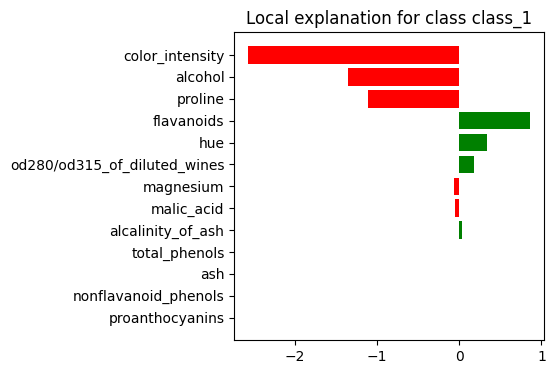

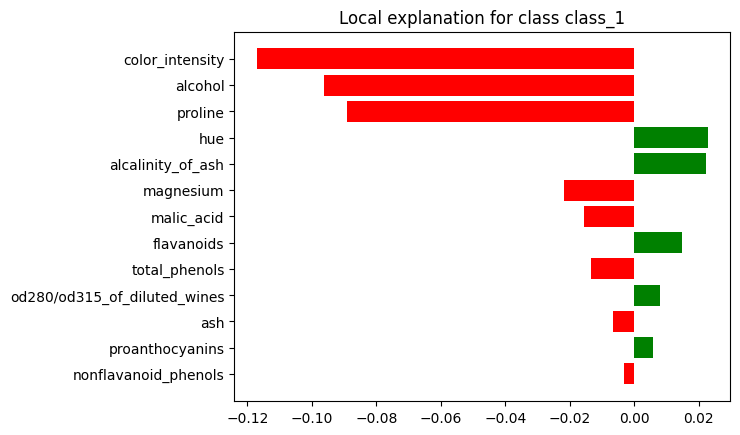

In [5]:
import matplotlib.pyplot as plt

exp.as_pyplot_figure()
plt.show()

exp_ridge.as_pyplot_figure()
plt.show()